# Imports

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.2 MB/s eta 0:00:00


In [3]:
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from google.colab import drive
from matplotlib.patches import FancyBboxPatch
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
    precision_score, precision_recall_curve, recall_score, roc_auc_score,
    roc_curve, RocCurveDisplay,make_scorer
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scipy.stats import loguniform, uniform
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


# اساسيات

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = '/content/drive/MyDrive/Alzheimer-Progression-Prediction/Data/Processed/'

df = pd.read_csv(path + 'df_clean.csv')

display(df.head())
df.info()

,TOTSCORE,TOTAL13,FAQTOTAL,BRAINVOL,VENTVOL,AVDEL30MIN,AVDELTOT,CATANIMSC,TOTAL_HIPPO,APOE4_COUNT,...,PTMARRY,AGE,MMSCORE,CDRSB,LIMMTOTAL,LDELTOTAL,RID,MONTH,PROGRESSOR,RAVLT_AVERAGE
0,10.670,18.67,0.0,1251.47,80.694003,5.0,6.0,15.0,5.817633,0,...,1,74.496920,28.0,0.0,14.0,11.0,2,0.0,0,8.166667
1,14.330,21.33,0.0,1178.02,43.714000,7.0,13.0,22.0,6.567308,0,...,1,67.852156,27.0,1.0,5.0,4.0,4,0.0,0,7.166667
2,8.670,14.67,0.0,1176.69,35.972000,5.0,15.0,19.0,7.095154,0,...,1,73.831622,29.0,0.0,13.0,12.0,5,0.0,0,6.833333
3,16.675,25.67,0.0,993.96,41.763000,1.0,7.0,13.0,5.818784,0,...,1,80.501027,25.0,0.5,6.0,3.0,6,0.0,0,5.666667
4,5.000,7.00,0.0,988.81,20.894000,9.0,13.0,22.0,6.634967,0,...,2,84.583162,28.0,0.0,19.0,16.0,8,0.0,0,10.166667


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TOTSCORE       2535 non-null   float64
 1   TOTAL13        2535 non-null   float64
 2   FAQTOTAL       2535 non-null   float64
 3   BRAINVOL       2535 non-null   float64
 4   VENTVOL        2535 non-null   float64
 5   AVDEL30MIN     2535 non-null   float64
 6   AVDELTOT       2535 non-null   float64
 7   CATANIMSC      2535 non-null   float64
 8   TOTAL_HIPPO    2535 non-null   float64
 9   APOE4_COUNT    2535 non-null   int64  
 10  DIAGNOSIS      2535 non-null   int64  
 11  PTGENDER       2535 non-null   float64
 12  PTEDUCAT       2535 non-null   float64
 13  PTMARRY        2535 non-null   int64  
 14  AGE            2535 non-null   float64
 15  MMSCORE        2535 non-null   float64
 16  CDRSB          2535 non-null   float64
 17  LIMMTOTAL      2535 non-null   float64
 18  LDELTOTA

In [ ]:
df.PROGRESSOR.value_counts()

,count
PROGRESSOR,
0,2304
1,231


# GENERAL USE IN ALL MODELS

In [6]:
# ME COOK
# U WATCH
PALETTE = ["#6C63FF", "#00C896", "#FF6B6B", "#FFC857", "#4CC9F0"]
model_features = [
    'PTGENDER',
    'PTEDUCAT',
    'PTMARRY',
    'APOE4_COUNT',
    'AGE',
    'LIMMTOTAL',
    'LDELTOTAL',
    'AVDEL30MIN',
    'AVDELTOT',
    'CATANIMSC',
    'MMSCORE',
    'CDRSB',
    'FAQTOTAL',
    'TOTSCORE',
    'TOTAL13',
    'BRAINVOL',
    'VENTVOL',
    'TOTAL_HIPPO',
    'RAVLT_AVERAGE']



scale_features = [f for f in model_features if f not in ['PTGENDER']]

X = df[model_features].copy()
y = df['PROGRESSOR'].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Dataset: {X.shape[0]} samples | {X.shape[1]} features")
print(f"Progressors: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"\n✅ Ready — use X, y, skf, scale_features in all models")


Dataset: 2535 samples | 19 features
Progressors: 231 (9.1%)

✅ Ready — use X, y, skf, scale_features in all models


# Logistic Reg

In [ ]:
"""
Logistic Regression — Optuna Hyperparameter Tuning
====================================================
Scorer : harmonic mean of Recall & F1 (balanced)
Tunes  : C, penalty, l1_ratio, class_weight
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    recall_score, f1_score,
    roc_auc_score, accuracy_score, precision_score, average_precision_score
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Scorer ────────────────────────────────────
def recall_f1_balance(y_true, y_pred):
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    if r + f == 0:
        return 0.0
    return 2 * r * f / (r + f)


# ── Optuna Tuning ─────────────────────────────
def tune_lr_optuna(X, y, scale_features, n_trials=100, cv=5, show_progress=True):
    """
    Bayesian Optimization via Optuna (TPE sampler).

    Returns
    -------
    best_params : dict  — best LR params
    best_score  : float — balanced recall-f1 CV score
    study       : optuna.Study
    best_model  : LogisticRegression fitted on full X, y
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    def objective(trial):
        penalty      = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
        C            = trial.suggest_float("C", 1e-4, 1e3, log=True)
        class_weight = trial.suggest_categorical("class_weight", ["balanced", "none"])
        l1_ratio     = trial.suggest_float("l1_ratio", 0.0, 1.0) if penalty == "elasticnet" else None

        scores = []
        for train_idx, val_idx in skf.split(X, y):
            X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

            scaler = StandardScaler()
            X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
            X_val[scale_features] = scaler.transform(X_val[scale_features])

            model = LogisticRegression(
                C            = C,
                penalty      = penalty,
                solver       = "saga",
                l1_ratio     = l1_ratio,
                class_weight = None if class_weight == "none" else class_weight,
                max_iter     = 1000,
                random_state = 42,
            )
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            scores.append(f1_score(y_val, y_pred, zero_division=0))

        return np.mean(scores)

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=show_progress)

    best = study.best_params
    cw   = None if best["class_weight"] == "none" else best["class_weight"]

    print(f"\n[LR Optuna] Best balanced score : {study.best_value:.4f}")
    print(f"[LR Optuna] Best params         : {best}")

    best_model = LogisticRegression(
        C            = best["C"],
        penalty      = best["penalty"],
        solver       = "saga",
        l1_ratio     = best.get("l1_ratio", None),
        class_weight = cw,
        max_iter     = 1000,
        random_state = 42,
    )
    best_model.fit(X, y)

    return {
        "best_params": best,
        "best_score":  study.best_value,
        "study":       study,
        "best_model":  best_model,
    }


# ── Evaluate (your fold-loop style) ──────────
def evaluate_best_model(best_model, X, y, scale_features, skf):
    fold_metrics, fold_data = [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

        scaler = StandardScaler()
        X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
        X_val[scale_features] = scaler.transform(X_val[scale_features])

        model = LogisticRegression(**best_model.get_params())
        model.fit(X_tr, y_tr)

        y_pred  = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        fold_metrics.append({
            "fold":      fold,
            "roc_auc":   roc_auc_score(y_val, y_proba),
            "accuracy":  accuracy_score(y_val, y_pred),
            "recall":    recall_score(y_val, y_pred),
            "precision": precision_score(y_val, y_pred, zero_division=0),
            "f1_score":  f1_score(y_val, y_pred, zero_division=0),
            "pr_auc":    average_precision_score(y_val, y_proba),
        })
        fold_data.append((y_val, y_pred, y_proba))

    metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
    best_fold  = int(metrics_df["f1_score"].idxmax())

    print(metrics_df.round(4).to_string())
    print(f"\nBest fold (F1) : {best_fold}")
    print(f"Mean Recall    : {metrics_df['recall'].mean():.4f} ± {metrics_df['recall'].std():.4f}")
    print(f"Mean F1        : {metrics_df['f1_score'].mean():.4f} ± {metrics_df['f1_score'].std():.4f}")

    return metrics_df, best_fold, fold_data


result     = tune_lr_optuna(X, y, scale_features)
metrics_df, best_fold, fold_data = evaluate_best_model(
    result["best_model"], X, y, scale_features, skf
)

  0%|          | 0/100 [00:00<?, ?it/s]


[LR Optuna] Best balanced score : 0.4943
[LR Optuna] Best params         : {'penalty': 'elasticnet', 'C': 0.03506953305723398, 'class_weight': 'balanced', 'l1_ratio': 0.7330702669394074}
      roc_auc  accuracy  recall  precision  f1_score  pr_auc
fold                                                        
1      0.8593    0.8185  0.8261     0.3115    0.4524  0.4121
2      0.8849    0.8383  0.8478     0.3421    0.4875  0.4554
3      0.9446    0.8600  1.0000     0.3932    0.5644  0.4920
4      0.9148    0.8245  0.8913     0.3280    0.4795  0.4768
5      0.8937    0.8343  0.8511     0.3419    0.4878  0.3969

Best fold (F1) : 3
Mean Recall    : 0.8833 ± 0.0694
Mean F1        : 0.4943 ± 0.0418


In [ ]:
# omar
# U WATCH
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
fold_metrics = []
fold_data    = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
    X_val[scale_features] = scaler.transform(X_val[scale_features])

    lr_model.fit(X_tr, y_tr)

    y_pred  = lr_model.predict(X_val)
    y_proba = lr_model.predict_proba(X_val)[:, 1]

    fold_metrics.append({
           "fold":      fold,
            "roc_auc":   roc_auc_score(y_val, y_proba),
            "accuracy":  accuracy_score(y_val, y_pred),
            "recall":    recall_score(y_val, y_pred),
            "precision": precision_score(y_val, y_pred, zero_division=0),
            "f1_score":  f1_score(y_val, y_pred, zero_division=0),
            "pr_auc":    average_precision_score(y_val, y_proba),
        })
    fold_data.append((y_val, y_pred, y_proba))

metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
best_fold  = int(metrics_df["f1_score"].idxmax())



In [ ]:
cols    = ["roc_auc", "accuracy", "recall", "precision", "f1_score", "pr_auc"]
headers = ["Fold", "ROC-AUC", "Accuracy", "Recall", "Precision", "F1", "PR-AUC"]
col_w   = 10
sep     = "┼".join(["─" * col_w] * len(headers))

print(f"\n  {'Logistic Regression results':^{col_w * len(headers)}}")
print("  ┌" + "┬".join(["─" * col_w] * len(headers)) + "┐")
print("  │" + "│".join(h.center(col_w) for h in headers) + "│")
print("  ├" + sep + "┤")

for fold, row in metrics_df.iterrows():
    marker = f" ★Fold {fold}" if fold == best_fold else f"  Fold {fold}"
    cells  = [marker.ljust(col_w)]
    for c in cols:
        cells.append(f"{row[c]:.3f}".center(col_w))
    print("  │" + "│".join(cells) + "│")

print("  ├" + sep + "┤")
avg_cells = [" Mean".ljust(col_w)]
std_cells = [" Std".ljust(col_w)]
for c in cols:
    avg_cells.append(f"{metrics_df[c].mean():.3f}".center(col_w))
    std_cells.append(f"±{metrics_df[c].std():.3f}".center(col_w))
print("  │" + "│".join(avg_cells) + "│")
print("  │" + "│".join(std_cells) + "│")
print("  └" + "┴".join(["─" * col_w] * len(headers)) + "┘\n")


                       Logistic Regression results                      
  ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │   Fold   │ ROC-AUC  │ Accuracy │  Recall  │Precision │    F1    │  PR-AUC  │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Fold 1  │  0.861   │  0.821   │  0.826   │  0.314   │  0.455   │  0.402   │
  │  Fold 2  │  0.886   │  0.830   │  0.804   │  0.325   │  0.463   │  0.420   │
  │ ★Fold 3  │  0.950   │  0.844   │  1.000   │  0.368   │  0.538   │  0.518   │
  │  Fold 4  │  0.905   │  0.824   │  0.891   │  0.328   │  0.480   │  0.467   │
  │  Fold 5  │  0.894   │  0.830   │  0.872   │  0.339   │  0.488   │  0.388   │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ Mean     │  0.899   │  0.830   │  0.879   │  0.335   │  0.485   │  0.439   │
  │ Std      │  ±0.033  │  ±0.009  │  ±0.076  │  ±0.021  │  ±0.033  │  ±0.053  │
  └──────────┴──────────┴──────────

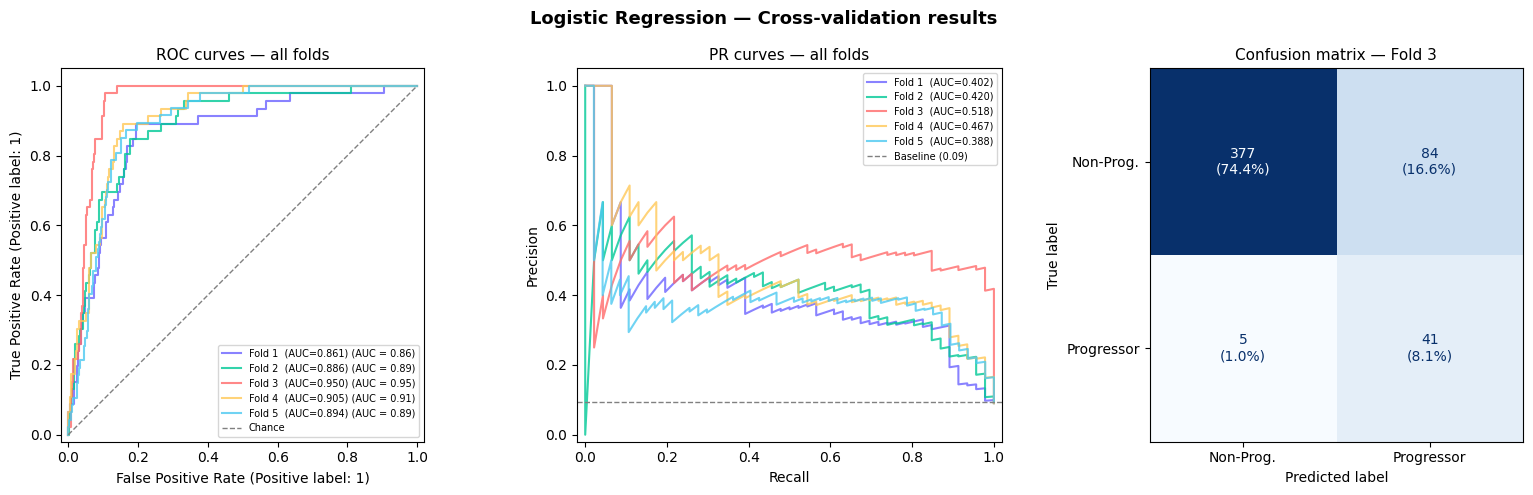

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Logistic Regression — Cross-validation results", fontsize=13, fontweight="bold")

# ── ROC curves (all folds) ────────────────────────────────────────────────
ax = axes[0]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    auc = metrics_df.loc[fold_num, "roc_auc"]
    RocCurveDisplay.from_predictions(
        y_val, y_proba, ax=ax,
        name=f"Fold {fold_num}  (AUC={auc:.3f})",
        color=PALETTE[idx % len(PALETTE)],
        lw=1.5, alpha=0.8,
    )
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_title("ROC curves — all folds", fontsize=11)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── PR curves (all folds) ─────────────────────────────────────────────────
ax = axes[1]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    pr_auc = metrics_df.loc[fold_num, "pr_auc"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall_vals, precision_vals,
            color=PALETTE[idx % len(PALETTE)],
            lw=1.5, alpha=0.8,
            label=f"Fold {fold_num}  (AUC={pr_auc:.3f})")
baseline = sum(fold_data[-1][0]) / len(fold_data[-1][0])
ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_title("PR curves — all folds", fontsize=11)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── Confusion matrix (last fold) ─────────────────────────────────────────
ax = axes[2]
y_val_last, y_pred_last, _ = fold_data[best_fold]
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_val_last, y_pred_last,
    ax=ax,
    display_labels=["Non-Prog.", "Progressor"],
    colorbar=False,
    cmap="Blues",
)
total = len(y_val_last)
for text_obj in cm_disp.text_.ravel():
    count = int(text_obj.get_text())
    text_obj.set_text(f"{count}\n({count/total*100:.1f}%)")
    text_obj.set_fontsize(10)
ax.set_title(f"Confusion matrix — Fold {best_fold}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# **SVM del chef**

In [ ]:
THRESHOLD = 0.3   # already in your code, now actually used

svc_final = SVC(
    kernel='linear',
    C=1,
    class_weight='balanced',
    probability=True,
    random_state=42
)

fold_metrics = []
fold_data    = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
    X_val[scale_features] = scaler.transform(X_val[scale_features])

    svc_final.fit(X_tr, y_tr)

    y_proba = svc_final.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= THRESHOLD).astype(int)

    fold_metrics.append({
        "fold":      fold,
        "roc_auc":   roc_auc_score(y_val, y_proba),
        "accuracy":  accuracy_score(y_val, y_pred),
        "recall":    recall_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "f1_score":  f1_score(y_val, y_pred, zero_division=0),
        "pr_auc":    average_precision_score(y_val, y_proba),
    })
    fold_data.append((y_val, y_pred, y_proba))

metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
best_fold  = int(metrics_df["f1_score"].idxmax())

In [ ]:
cols    = ["roc_auc", "accuracy", "recall", "precision", "f1_score", "pr_auc"]
headers = ["Fold", "ROC-AUC", "Accuracy", "Recall", "Precision", "F1", "PR-AUC"]
col_w   = 10
sep     = "┼".join(["─" * col_w] * len(headers))

print(f"\n  {'SVM results':^{col_w * len(headers)}}")
print("  ┌" + "┬".join(["─" * col_w] * len(headers)) + "┐")
print("  │" + "│".join(h.center(col_w) for h in headers) + "│")
print("  ├" + sep + "┤")

for fold, row in metrics_df.iterrows():
    marker = f" ★Fold {fold}" if fold == best_fold else f"  Fold {fold}"
    cells  = [marker.ljust(col_w)]
    for c in cols:
        cells.append(f"{row[c]:.3f}".center(col_w))
    print("  │" + "│".join(cells) + "│")

print("  ├" + sep + "┤")
avg_cells = [" Mean".ljust(col_w)]
std_cells = [" Std".ljust(col_w)]
for c in cols:
    avg_cells.append(f"{metrics_df[c].mean():.3f}".center(col_w))
    std_cells.append(f"±{metrics_df[c].std():.3f}".center(col_w))
print("  │" + "│".join(avg_cells) + "│")
print("  │" + "│".join(std_cells) + "│")
print("  └" + "┴".join(["─" * col_w] * len(headers)) + "┘\n")


                               SVM results                              
  ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │   Fold   │ ROC-AUC  │ Accuracy │  Recall  │Precision │    F1    │  PR-AUC  │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Fold 1  │  0.860   │  0.882   │  0.435   │  0.370   │  0.400   │  0.393   │
  │  Fold 2  │  0.883   │  0.895   │  0.457   │  0.429   │  0.442   │  0.427   │
  │ ★Fold 3  │  0.951   │  0.911   │  0.587   │  0.509   │  0.545   │  0.521   │
  │  Fold 4  │  0.910   │  0.892   │  0.478   │  0.415   │  0.444   │  0.467   │
  │  Fold 5  │  0.898   │  0.888   │  0.489   │  0.411   │  0.447   │  0.396   │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ Mean     │  0.900   │  0.893   │  0.489   │  0.427   │  0.456   │  0.441   │
  │ Std      │  ±0.034  │  ±0.011  │  ±0.059  │  ±0.051  │  ±0.054  │  ±0.054  │
  └──────────┴──────────┴──────────

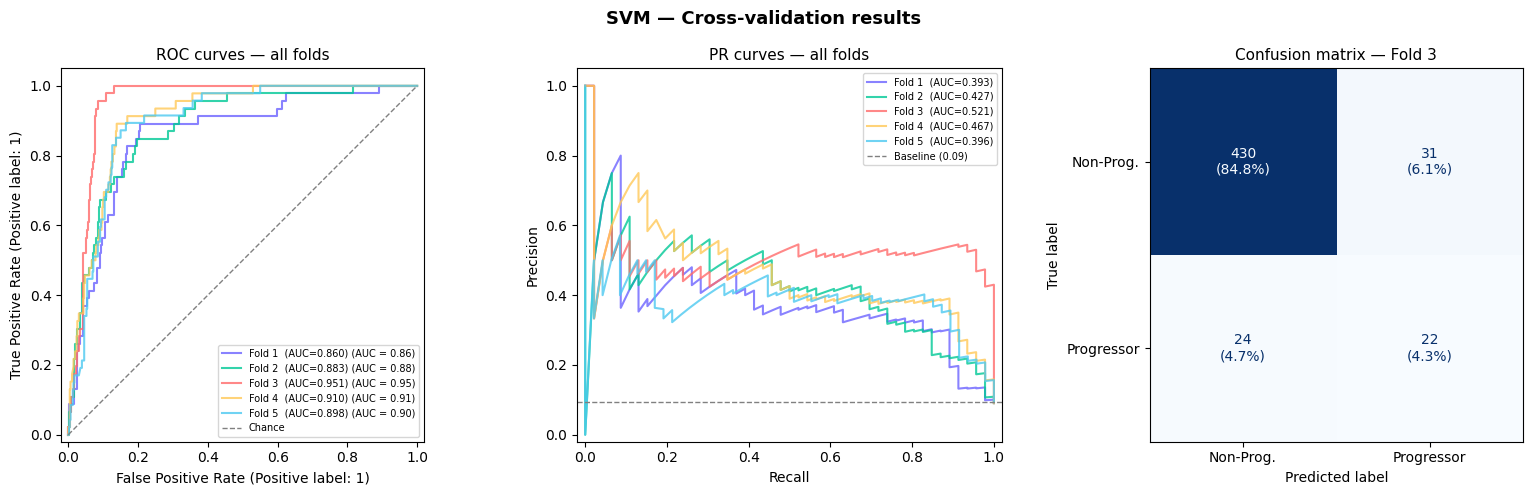

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("SVM — Cross-validation results", fontsize=13, fontweight="bold")

# ── ROC curves (all folds) ────────────────────────────────────────────────
ax = axes[0]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    auc = metrics_df.loc[fold_num, "roc_auc"]
    RocCurveDisplay.from_predictions(
        y_val, y_proba, ax=ax,
        name=f"Fold {fold_num}  (AUC={auc:.3f})",
        color=PALETTE[idx % len(PALETTE)],
        lw=1.5, alpha=0.8,
    )
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_title("ROC curves — all folds", fontsize=11)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── PR curves (all folds) ─────────────────────────────────────────────────
ax = axes[1]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    pr_auc = metrics_df.loc[fold_num, "pr_auc"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall_vals, precision_vals,
            color=PALETTE[idx % len(PALETTE)],
            lw=1.5, alpha=0.8,
            label=f"Fold {fold_num}  (AUC={pr_auc:.3f})")
baseline = sum(fold_data[-1][0]) / len(fold_data[-1][0])
ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_title("PR curves — all folds", fontsize=11)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── Confusion matrix (last fold) ─────────────────────────────────────────
ax = axes[2]
y_val_last, y_pred_last, _ = fold_data[best_fold]
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_val_last, y_pred_last,
    ax=ax,
    display_labels=["Non-Prog.", "Progressor"],
    colorbar=False,
    cmap="Blues",
)
total = len(y_val_last)
for text_obj in cm_disp.text_.ravel():
    count = int(text_obj.get_text())
    text_obj.set_text(f"{count}\n({count/total*100:.1f}%)")
    text_obj.set_fontsize(10)
ax.set_title(f"Confusion matrix — Fold {best_fold}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# **XGBoost del chef**




In [ ]:
"""
XGBoost (gblinear) — Optuna Hyperparameter + Threshold Tuning
===============================================================
Scorer : harmonic mean of Recall & F1 (balanced)
Tunes  : reg_alpha, reg_lambda, learning_rate, n_estimators,
         scale_pos_weight, threshold
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    recall_score, f1_score,
    roc_auc_score, accuracy_score, precision_score, average_precision_score
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ── Scorer ────────────────────────────────────
def recall_f1_balance(y_true, y_pred):
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    if r + f == 0:
        return 0.0
    return 2 * r * f / (r + f)


# ── Optuna Tuning ─────────────────────────────
def tune_xgb_optuna(X, y, scale_features, n_trials=100, cv=5, show_progress=True):
    """
    Bayesian Optimization via Optuna (TPE sampler).

    Returns
    -------
    best_params    : dict  — best XGBClassifier params (no threshold)
    best_threshold : float — replaces your hardcoded 0.55
    best_score     : float — balanced recall-f1 CV score
    study          : optuna.Study
    best_model     : XGBClassifier fitted on full X, y
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    def objective(trial):
        params = dict(
            booster          = "gblinear",
            objective        = "binary:logistic",
            eval_metric      = "auc",
            updater          = "coord_descent",
            random_state     = 42,
            verbosity        = 0,
            reg_alpha        = trial.suggest_float("reg_alpha",        1e-4, 1.0,  log=True),
            reg_lambda       = trial.suggest_float("reg_lambda",       1e-2, 10.0, log=True),
            learning_rate    = trial.suggest_float("learning_rate",    1e-3, 0.5,  log=True),
            n_estimators     = trial.suggest_int(  "n_estimators",     50,   600),
            scale_pos_weight = trial.suggest_float("scale_pos_weight", 1.0,  15.0),
        )
        threshold = trial.suggest_float("threshold", 0.2, 0.65)

        scores = []
        for train_idx, val_idx in skf.split(X, y):
            X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

            scaler = StandardScaler()
            X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
            X_val[scale_features] = scaler.transform(X_val[scale_features])

            model = xgb.XGBClassifier(**params)
            model.fit(X_tr, y_tr)

            y_proba = model.predict_proba(X_val)[:, 1]
            y_pred  = (y_proba >= threshold).astype(int)
            scores.append(recall_f1_balance(y_val, y_pred))

        return np.mean(scores)

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=show_progress)

    best     = study.best_params
    best_thr = best.pop("threshold")

    best_params = dict(
        booster          = "gblinear",
        objective        = "binary:logistic",
        eval_metric      = "auc",
        updater          = "coord_descent",
        random_state     = 42,
        verbosity        = 0,
        **best,
    )

    print(f"\n[XGB Optuna] Best balanced score : {study.best_value:.4f}")
    print(f"[XGB Optuna] Best threshold      : {best_thr:.4f}  (was 0.55)")
    print(f"[XGB Optuna] Best params         : {best}")

    best_model = xgb.XGBClassifier(**best_params)
    best_model.fit(X, y)

    return {
        "best_params":    best,
        "best_threshold": best_thr,
        "best_score":     study.best_value,
        "study":          study,
        "best_model":     best_model,
    }


# ── Evaluate (your fold-loop style) ──────────
def evaluate_best_model(best_model, best_threshold, X, y, scale_features, skf):
    fold_metrics, fold_data = [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

        scaler = StandardScaler()
        X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
        X_val[scale_features] = scaler.transform(X_val[scale_features])

        model = xgb.XGBClassifier(**best_model.get_params())
        model.fit(X_tr, y_tr)

        y_proba = model.predict_proba(X_val)[:, 1]
        y_pred  = (y_proba >= best_threshold).astype(int)

        fold_metrics.append({
            "fold":      fold,
            "roc_auc":   roc_auc_score(y_val, y_proba),
            "accuracy":  accuracy_score(y_val, y_pred),
            "recall":    recall_score(y_val, y_pred),
            "precision": precision_score(y_val, y_pred, zero_division=0),
            "f1_score":  f1_score(y_val, y_pred, zero_division=0),
            "pr_auc":    average_precision_score(y_val, y_proba),
        })
        fold_data.append((y_val, y_pred, y_proba))

    metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
    best_fold  = int(metrics_df["f1_score"].idxmax())

    print(f"\nThreshold used  : {best_threshold:.4f}  (was 0.55)")
    print(metrics_df.round(4).to_string())
    print(f"\nBest fold (F1)  : {best_fold}")
    print(f"Mean Recall     : {metrics_df['recall'].mean():.4f} ± {metrics_df['recall'].std():.4f}")
    print(f"Mean F1         : {metrics_df['f1_score'].mean():.4f} ± {metrics_df['f1_score'].std():.4f}")

    return metrics_df, best_fold, fold_data


result     = tune_xgb_optuna(X, y, scale_features)   # or tune_xgb_optuna
THRESHOLD  = result["best_threshold"]
metrics_df, best_fold, fold_data = evaluate_best_model(
    result["best_model"], THRESHOLD, X, y, scale_features, skf
)

  0%|          | 0/100 [00:00<?, ?it/s]


[XGB Optuna] Best balanced score : 0.6335
[XGB Optuna] Best threshold      : 0.4436  (was 0.55)
[XGB Optuna] Best params         : {'reg_alpha': 0.000272362399538495, 'reg_lambda': 0.011466623878428507, 'learning_rate': 0.17942349031503532, 'n_estimators': 232, 'scale_pos_weight': 6.867751160765596}

Threshold used  : 0.4436  (was 0.55)
      roc_auc  accuracy  recall  precision  f1_score  pr_auc
fold                                                        
1      0.8602    0.8245  0.7609     0.3097    0.4403  0.4078
2      0.8864    0.8442  0.8261     0.3486    0.4903  0.4518
3      0.9468    0.8580  1.0000     0.3898    0.5610  0.4998
4      0.9108    0.8383  0.8913     0.3475    0.5000  0.4745
5      0.8943    0.8462  0.8511     0.3604    0.5063  0.3803

Best fold (F1)  : 3
Mean Recall     : 0.8659 ± 0.0887
Mean F1         : 0.4996 ± 0.0431


In [ ]:
# Class weight for imbalance
neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos_weight = neg / pos * 0.5
print(f"scale_pos_weight: {scale_pos_weight:.2f}  ({neg} neg / {pos} pos)")

THRESHOLD = 0.3   # lower than 0.5 → prioritises recall

fold_metrics = []
fold_data    = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
    X_val[scale_features] = scaler.transform(X_val[scale_features])
    model = xgb.XGBClassifier(
    booster='gblinear',
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    reg_alpha=0.02,    # L1 — important for gblinear
    reg_lambda=0.7,   # L2
    learning_rate=0.05,
    n_estimators=300,
    random_state=42,
    verbosity=0,
    updater='coord_descent'
    )
    model.fit(X_tr, y_tr)

    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= THRESHOLD).astype(int)

    fold_metrics.append({
        "fold":      fold,
        "roc_auc":   roc_auc_score(y_val, y_proba),
        "accuracy":  accuracy_score(y_val, y_pred),
        "recall":    recall_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "f1_score":  f1_score(y_val, y_pred, zero_division=0),
        "pr_auc":    average_precision_score(y_val, y_proba),
    })
    fold_data.append((y_val, y_pred, y_proba))

metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
best_fold  = int(metrics_df["f1_score"].idxmax())

scale_pos_weight: 4.99  (2304 neg / 231 pos)


In [ ]:
cols    = ["roc_auc", "accuracy", "recall", "precision", "f1_score", "pr_auc"]
headers = ["Fold", "ROC-AUC", "Accuracy", "Recall", "Precision", "F1", "PR-AUC"]
col_w   = 10
sep     = "┼".join(["─" * col_w] * len(headers))

print(f"\n  {'XGBOOST results':^{col_w * len(headers)}}")
print("  ┌" + "┬".join(["─" * col_w] * len(headers)) + "┐")
print("  │" + "│".join(h.center(col_w) for h in headers) + "│")
print("  ├" + sep + "┤")

for fold, row in metrics_df.iterrows():
    marker = f" ★Fold {fold}" if fold == best_fold else f"  Fold {fold}"
    cells  = [marker.ljust(col_w)]
    for c in cols:
        cells.append(f"{row[c]:.3f}".center(col_w))
    print("  │" + "│".join(cells) + "│")

print("  ├" + sep + "┤")
avg_cells = [" Mean".ljust(col_w)]
std_cells = [" Std".ljust(col_w)]
for c in cols:
    avg_cells.append(f"{metrics_df[c].mean():.3f}".center(col_w))
    std_cells.append(f"±{metrics_df[c].std():.3f}".center(col_w))
print("  │" + "│".join(avg_cells) + "│")
print("  │" + "│".join(std_cells) + "│")
print("  └" + "┴".join(["─" * col_w] * len(headers)) + "┘\n")


                             XGBOOST results                            
  ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │   Fold   │ ROC-AUC  │ Accuracy │  Recall  │Precision │    F1    │  PR-AUC  │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Fold 1  │  0.862   │  0.759   │  0.891   │  0.259   │  0.402   │  0.400   │
  │  Fold 2  │  0.875   │  0.765   │  0.891   │  0.265   │  0.408   │  0.424   │
  │ ★Fold 3  │  0.931   │  0.805   │  1.000   │  0.317   │  0.482   │  0.450   │
  │  Fold 4  │  0.916   │  0.767   │  0.978   │  0.278   │  0.433   │  0.464   │
  │  Fold 5  │  0.893   │  0.777   │  0.936   │  0.286   │  0.438   │  0.406   │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ Mean     │  0.896   │  0.775   │  0.939   │  0.281   │  0.432   │  0.429   │
  │ Std      │  ±0.028  │  ±0.018  │  ±0.050  │  ±0.023  │  ±0.032  │  ±0.028  │
  └──────────┴──────────┴──────────

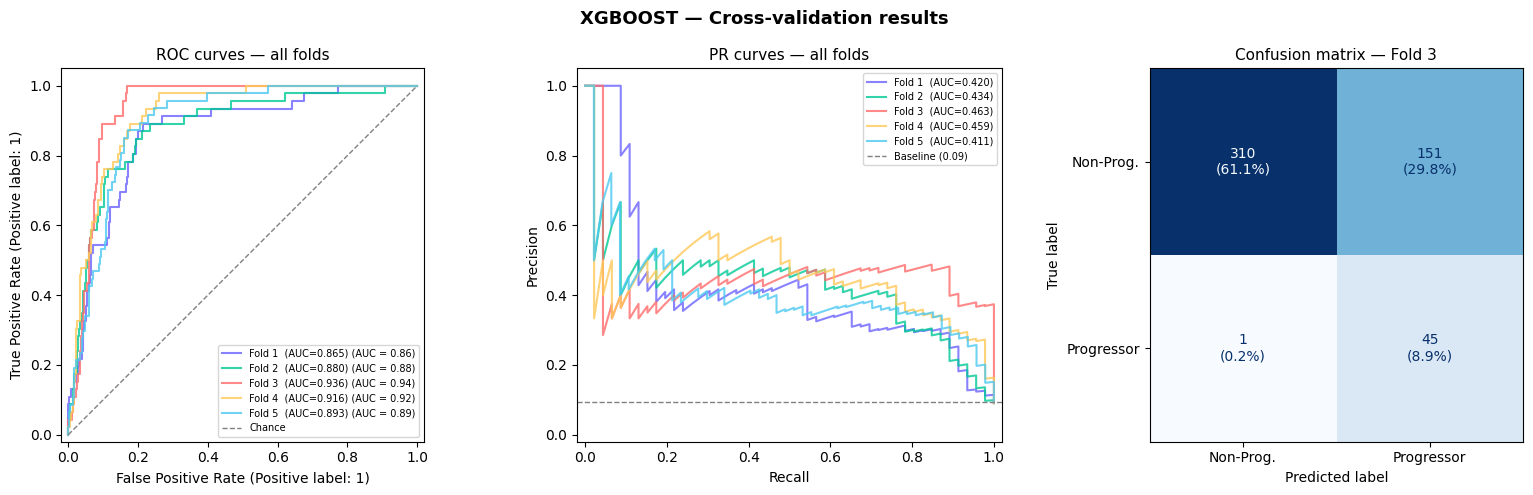

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("XGBOOST — Cross-validation results", fontsize=13, fontweight="bold")

# ── ROC curves (all folds) ────────────────────────────────────────────────
ax = axes[0]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    auc = metrics_df.loc[fold_num, "roc_auc"]
    RocCurveDisplay.from_predictions(
        y_val, y_proba, ax=ax,
        name=f"Fold {fold_num}  (AUC={auc:.3f})",
        color=PALETTE[idx % len(PALETTE)],
        lw=1.5, alpha=0.8,
    )
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_title("ROC curves — all folds", fontsize=11)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── PR curves (all folds) ─────────────────────────────────────────────────
ax = axes[1]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    pr_auc = metrics_df.loc[fold_num, "pr_auc"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall_vals, precision_vals,
            color=PALETTE[idx % len(PALETTE)],
            lw=1.5, alpha=0.8,
            label=f"Fold {fold_num}  (AUC={pr_auc:.3f})")
baseline = sum(fold_data[-1][0]) / len(fold_data[-1][0])
ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_title("PR curves — all folds", fontsize=11)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── Confusion matrix (last fold) ─────────────────────────────────────────
ax = axes[2]
y_val_last, y_pred_last, _ = fold_data[best_fold]
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_val_last, y_pred_last,
    ax=ax,
    display_labels=["Non-Prog.", "Progressor"],
    colorbar=False,
    cmap="Blues",
)
total = len(y_val_last)
for text_obj in cm_disp.text_.ravel():
    count = int(text_obj.get_text())
    text_obj.set_text(f"{count}\n({count/total*100:.1f}%)")
    text_obj.set_fontsize(10)
ax.set_title(f"Confusion matrix — Fold {best_fold}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# الغابه العشوائيه

In [ ]:
THRESHOLD = 0.2

rf_final = RandomForestClassifier(
    n_estimators = 100,
    max_depth = None,
    min_samples_leaf= 4,
    class_weight= 'balanced_subsample',
    random_state=42
)

fold_metrics = []
fold_data    = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
    X_val[scale_features] = scaler.transform(X_val[scale_features])

    rf_final.fit(X_tr, y_tr)

    y_proba = rf_final.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= THRESHOLD).astype(int)

    fold_metrics.append({
        "fold":      fold,
        "roc_auc":   roc_auc_score(y_val, y_proba),
        "accuracy":  accuracy_score(y_val, y_pred),
        "recall":    recall_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "f1_score":  f1_score(y_val, y_pred, zero_division=0),
        "pr_auc":    average_precision_score(y_val, y_proba),
    })
    fold_data.append((y_val, y_pred, y_proba))

metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
best_fold  = int(metrics_df["f1_score"].idxmax())

In [ ]:
cols    = ["roc_auc", "accuracy", "recall", "precision", "f1_score", "pr_auc"]
headers = ["Fold", "ROC-AUC", "Accuracy", "Recall", "Precision", "F1", "PR-AUC"]
col_w   = 10
sep     = "┼".join(["─" * col_w] * len(headers))

print(f"\n  {'Random Forest results':^{col_w * len(headers)}}")
print("  ┌" + "┬".join(["─" * col_w] * len(headers)) + "┐")
print("  │" + "│".join(h.center(col_w) for h in headers) + "│")
print("  ├" + sep + "┤")

for fold, row in metrics_df.iterrows():
    marker = f" ★Fold {fold}" if fold == best_fold else f"  Fold {fold}"
    cells  = [marker.ljust(col_w)]
    for c in cols:
        cells.append(f"{row[c]:.3f}".center(col_w))
    print("  │" + "│".join(cells) + "│")

print("  ├" + sep + "┤")
avg_cells = [" Mean".ljust(col_w)]
std_cells = [" Std".ljust(col_w)]
for c in cols:
    avg_cells.append(f"{metrics_df[c].mean():.3f}".center(col_w))
    std_cells.append(f"±{metrics_df[c].std():.3f}".center(col_w))
print("  │" + "│".join(avg_cells) + "│")
print("  │" + "│".join(std_cells) + "│")
print("  └" + "┴".join(["─" * col_w] * len(headers)) + "┘\n")


                          Random Forest results                         
  ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │   Fold   │ ROC-AUC  │ Accuracy │  Recall  │Precision │    F1    │  PR-AUC  │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Fold 1  │  0.882   │  0.809   │  0.848   │  0.302   │  0.446   │  0.429   │
  │  Fold 2  │  0.895   │  0.832   │  0.870   │  0.336   │  0.485   │  0.512   │
  │ ★Fold 3  │  0.937   │  0.846   │  1.000   │  0.371   │  0.541   │  0.482   │
  │  Fold 4  │  0.927   │  0.811   │  0.891   │  0.311   │  0.461   │  0.560   │
  │  Fold 5  │  0.911   │  0.832   │  0.851   │  0.339   │  0.485   │  0.499   │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ Mean     │  0.911   │  0.826   │  0.892   │  0.332   │  0.483   │  0.496   │
  │ Std      │  ±0.023  │  ±0.016  │  ±0.063  │  ±0.027  │  ±0.036  │  ±0.048  │
  └──────────┴──────────┴──────────

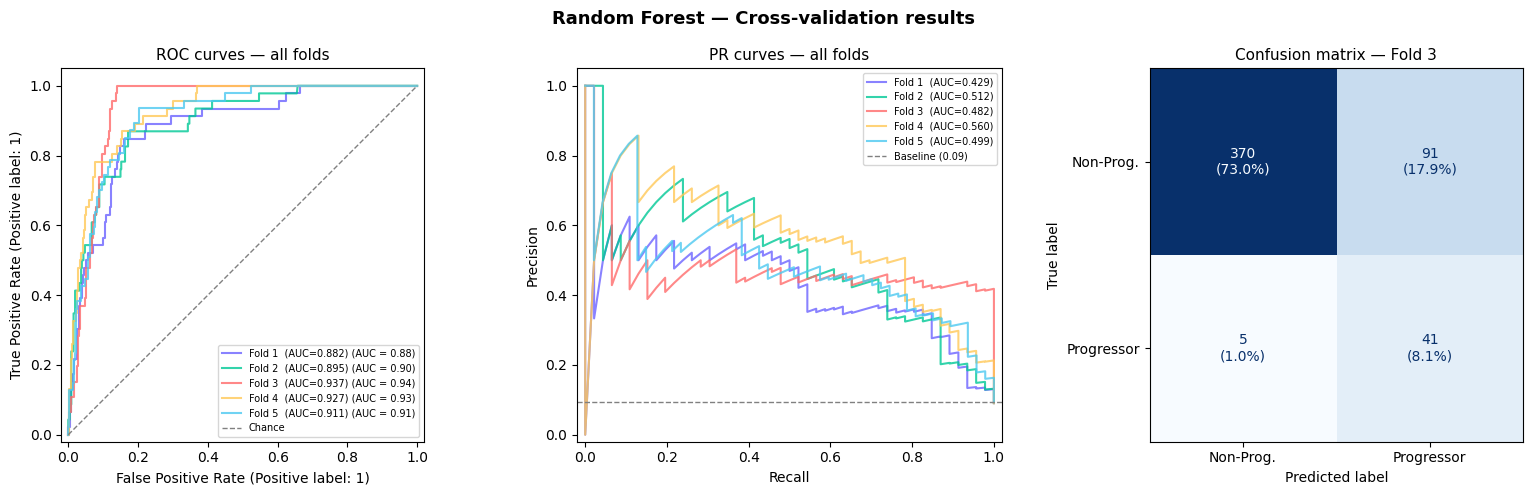

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Random Forest — Cross-validation results", fontsize=13, fontweight="bold")

# ── ROC curves (all folds) ────────────────────────────────────────────────
ax = axes[0]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    auc = metrics_df.loc[fold_num, "roc_auc"]
    RocCurveDisplay.from_predictions(
        y_val, y_proba, ax=ax,
        name=f"Fold {fold_num}  (AUC={auc:.3f})",
        color=PALETTE[idx % len(PALETTE)],
        lw=1.5, alpha=0.8,
    )
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_title("ROC curves — all folds", fontsize=11)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── PR curves (all folds) ─────────────────────────────────────────────────
ax = axes[1]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    pr_auc = metrics_df.loc[fold_num, "pr_auc"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall_vals, precision_vals,
            color=PALETTE[idx % len(PALETTE)],
            lw=1.5, alpha=0.8,
            label=f"Fold {fold_num}  (AUC={pr_auc:.3f})")
baseline = sum(fold_data[-1][0]) / len(fold_data[-1][0])
ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_title("PR curves — all folds", fontsize=11)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── Confusion matrix (last fold) ─────────────────────────────────────────
ax = axes[2]
y_val_last, y_pred_last, _ = fold_data[best_fold]
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_val_last, y_pred_last,
    ax=ax,
    display_labels=["Non-Prog.", "Progressor"],
    colorbar=False,
    cmap="Blues",
)
total = len(y_val_last)
for text_obj in cm_disp.text_.ravel():
    count = int(text_obj.get_text())
    text_obj.set_text(f"{count}\n({count/total*100:.1f}%)")
    text_obj.set_fontsize(10)
ax.set_title(f"Confusion matrix — Fold {best_fold}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# 🕸️الشبكه العنكبتويه🕸️

In [ ]:
tf.random.set_seed(42)

# Class weight for imbalance (same logic as XGBoost)
neg, pos = (y == 0).sum(), (y == 1).sum()
class_weight =  {0: 1.0, 1: neg / pos * 1.3}
print(f"Class weight for Progressor: {class_weight[1]:.2f}")

def build_model(input_dim):
    inp = keras.Input(shape=(input_dim,))

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model

# ── 5-Fold CV (same skf, X, y, scale_features as all other models) ────────
THRESHOLD  = 0.5   # lower than 0.5 → prioritises recall
EPOCHS     = 300
BATCH_SIZE = 8

fold_metrics_nn = []
fold_data_nn    = []

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, mode='min',
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10,
                      mode='min', min_lr=1e-6, verbose=0)
]



fold_metrics = []
fold_data    = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr,  y_val = y.iloc[train_idx],         y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[scale_features]  = scaler.fit_transform(X_tr[scale_features])
    X_val[scale_features] = scaler.transform(X_val[scale_features])

    tf.random.set_seed(42 + fold)
    model = build_model(X_tr.shape[1])
    model.fit(X_tr, y_tr,
              validation_data=(X_val, y_val),
              epochs=EPOCHS, batch_size=BATCH_SIZE,
              class_weight=class_weight,
              callbacks=callbacks, verbose=0)

    y_proba = rf_final.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= THRESHOLD).astype(int)

    fold_metrics.append({
        "fold":      fold,
        "roc_auc":   roc_auc_score(y_val, y_proba),
        "accuracy":  accuracy_score(y_val, y_pred),
        "recall":    recall_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "f1_score":  f1_score(y_val, y_pred, zero_division=0),
        "pr_auc":    average_precision_score(y_val, y_proba),
    })
    fold_data.append((y_val, y_pred, y_proba))

metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
best_fold  = int(metrics_df["f1_score"].idxmax())

Class weight for Progressor: 12.97


In [ ]:
cols    = ["roc_auc", "accuracy", "recall", "precision", "f1_score", "pr_auc"]
headers = ["Fold", "ROC-AUC", "Accuracy", "Recall", "Precision", "F1", "PR-AUC"]
col_w   = 10
sep     = "┼".join(["─" * col_w] * len(headers))

print(f"\n  {'MLP results':^{col_w * len(headers)}}")
print("  ┌" + "┬".join(["─" * col_w] * len(headers)) + "┐")
print("  │" + "│".join(h.center(col_w) for h in headers) + "│")
print("  ├" + sep + "┤")

for fold, row in metrics_df.iterrows():
    marker = f" ★Fold {fold}" if fold == best_fold else f"  Fold {fold}"
    cells  = [marker.ljust(col_w)]
    for c in cols:
        cells.append(f"{row[c]:.3f}".center(col_w))
    print("  │" + "│".join(cells) + "│")

print("  ├" + sep + "┤")
avg_cells = [" Mean".ljust(col_w)]
std_cells = [" Std".ljust(col_w)]
for c in cols:
    avg_cells.append(f"{metrics_df[c].mean():.3f}".center(col_w))
    std_cells.append(f"±{metrics_df[c].std():.3f}".center(col_w))
print("  │" + "│".join(avg_cells) + "│")
print("  │" + "│".join(std_cells) + "│")
print("  └" + "┴".join(["─" * col_w] * len(headers)) + "┘\n")


                               MLP results                              
  ┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │   Fold   │ ROC-AUC  │ Accuracy │  Recall  │Precision │    F1    │  PR-AUC  │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │  Fold 1  │  0.993   │  0.966   │  0.913   │  0.764   │  0.832   │  0.945   │
  │  Fold 2  │  0.990   │  0.957   │  0.913   │  0.700   │  0.792   │  0.915   │
  │  Fold 3  │  0.996   │  0.964   │  1.000   │  0.719   │  0.836   │  0.964   │
  │ ★Fold 4  │  0.995   │  0.968   │  0.913   │  0.778   │  0.840   │  0.956   │
  │  Fold 5  │  0.911   │  0.897   │  0.638   │  0.462   │  0.536   │  0.499   │
  ├──────────┼──────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ Mean     │  0.977   │  0.951   │  0.875   │  0.684   │  0.767   │  0.856   │
  │ Std      │  ±0.037  │  ±0.030  │  ±0.138  │  ±0.129  │  ±0.131  │  ±0.200  │
  └──────────┴──────────┴──────────

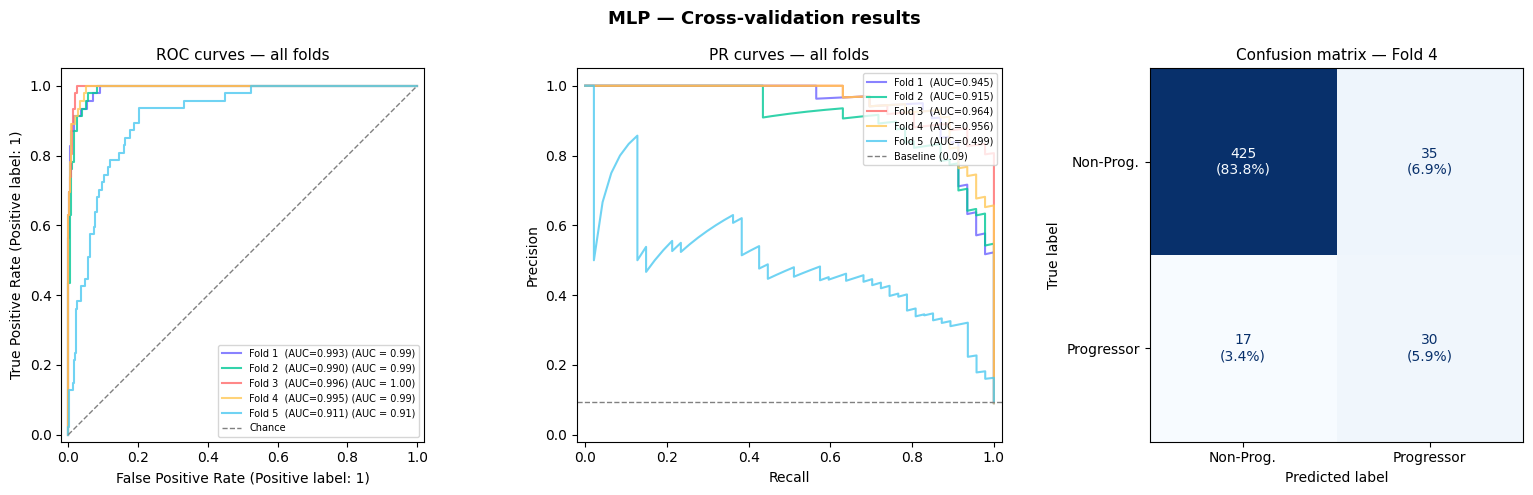

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("MLP — Cross-validation results", fontsize=13, fontweight="bold")

# ── ROC curves (all folds) ────────────────────────────────────────────────
ax = axes[0]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    auc = metrics_df.loc[fold_num, "roc_auc"]
    RocCurveDisplay.from_predictions(
        y_val, y_proba, ax=ax,
        name=f"Fold {fold_num}  (AUC={auc:.3f})",
        color=PALETTE[idx % len(PALETTE)],
        lw=1.5, alpha=0.8,
    )
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_title("ROC curves — all folds", fontsize=11)
ax.legend(fontsize=7, loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── PR curves (all folds) ─────────────────────────────────────────────────
ax = axes[1]
for idx, (y_val, _, y_proba) in enumerate(fold_data):
    fold_num = idx + 1
    pr_auc = metrics_df.loc[fold_num, "pr_auc"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
    ax.plot(recall_vals, precision_vals,
            color=PALETTE[idx % len(PALETTE)],
            lw=1.5, alpha=0.8,
            label=f"Fold {fold_num}  (AUC={pr_auc:.3f})")
baseline = sum(fold_data[-1][0]) / len(fold_data[-1][0])
ax.axhline(baseline, linestyle="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_title("PR curves — all folds", fontsize=11)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

# ── Confusion matrix (last fold) ─────────────────────────────────────────
ax = axes[2]
y_val_last, y_pred_last, _ = fold_data[best_fold]
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_val_last, y_pred_last,
    ax=ax,
    display_labels=["Non-Prog.", "Progressor"],
    colorbar=False,
    cmap="Blues",
)
total = len(y_val_last)
for text_obj in cm_disp.text_.ravel():
    count = int(text_obj.get_text())
    text_obj.set_text(f"{count}\n({count/total*100:.1f}%)")
    text_obj.set_fontsize(10)
ax.set_title(f"Confusion matrix — Fold {best_fold}", fontsize=11)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

# مجلس الشعب

In [ ]:
#Hi ahmed
#Hi omar
#ana nadeem
#Karim galkooo
#nadeem shof el 2 models dol
#HI KIMO
#hru
#DEAR AHMED,OMAR THIS THE WORST MODELS HUMANS HAVE EVER MADE
#plz ask the leader for guidance
#NOT BEST REGARDS, عده ذكيه تيم  👎
#best regards for u kimo
#                                 BEST TEAM LEADER 😎
#I will fix this shit b3d gamen league keda.
#USE THE FEATURES IN GENARL USE CELL AND scale_features and skf

In [ ]:
# LOTS OF LOVE TO ALL THE TEAM WHITE MEMBERS 🤍

In [ ]:
# (25%)² (LOTS OF LOVE TO ALL THE TEAM BLACK MEMBERS)

In [ ]:
# 1000%(LOTS OF LOVE TO ALL THE TEAM MEMBERS THAT PLAY LEAGUE W Overwatch(لنا عوده))

In [ ]:
# (Lots of hate to all the team black members)²

In [ ]:
# lots of hate to all ratatouille and michelin

In [ ]:
# KHOBZA W SHAWRMA BEST FAST FOOD RESTURANT IN GIZA